# 02-05 - Two Authorities, One Town

The municipality publishes one parcel file for Princeton and the State of New Jersey publishes another, and they do not hold the same number of parcels. Both are right about something. In this notebook we join the two on a key we have to build ourselves, watch three joins fail without a single error, and read what the parcels the two offices disagree about have in common. On the way we ask which block a parcel is in twice, once of the attribute and once of the map, and get two different answers. Then we turn to the stormwater inlets, whose inspection record turns out to be a map of something other than inspections, and whose coordinates are stored twice and do not always agree.

This notebook is self-paced and not assessed. Save your own copy first, with `-mywork` in the name.

In [1]:
import json

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## Two files, two counts

The municipality's parcels come from its own ArcGIS Online organisation, in New Jersey State Plane feet, with a packed parcel identifier, the block, lot and qualifier that the assessor uses and a street location, and nothing else, because the municipality stripped the rest before publishing. The State's file is the parcel composite that NJGIN publishes for the whole of New Jersey, in Web Mercator, carrying the tax list, i.e. the assessed values and the property class. Neither has an owner column, because neither was asked for one:

In [2]:
municipal = gpd.read_file("data/princeton_municipal.gpkg", layer="parcels")
state = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels")
reference = json.load(open("data/ground_truth.json"))["p02"]

print(f"municipality  {len(municipal):,} parcels in {municipal.crs}   columns {list(municipal.columns)}")
print(f"State         {len(state):,} parcels in {state.crs}")
print(f"reference     {reference['authorities']['municipal_rows']:,} and {reference['authorities']['state_rows']:,}")

municipality  8,874 parcels in EPSG:6527   columns ['propid', 'block', 'lot', 'qualifier', 'property_location', 'geometry']
State         8,391 parcels in EPSG:3857
reference     8,874 and 8,391


Nearly five hundred parcels apart, for one town, from two offices that both keep the official list. Before asking who is right, we need to be able to say which parcel in one file is which parcel in the other, and there is no shared identifier column. There is, however, a shared system. Every parcel in New Jersey is named by its block, its lot, and an optional qualifier, and both files carry all three, in their own way:

In [3]:
municipal[["propid", "block", "lot", "qualifier", "property_location"]].head(6)

,propid,block,lot,qualifier,property_location
0,11140680200002,6802,2,NaN,49 WILSON RD
1,11140680200046001,6802,46.01,NaN,192 BAYARD LANE
2,11140680200046002,6802,46.02,NaN,188 BAYARD LANE
3,11140680200043,6802,43,NaN,190 BAYARD LANE
4,11140680200042,6802,42,NaN,196 BAYARD LANE
5,11140680200041,6802,41,NaN,22 DUFFIELD PLACE


In [4]:
state[["PAMS_PIN", "PCLBLOCK", "PCLLOT", "PCLQCODE", "PROP_CLASS", "PROP_LOC"]].head(6)

,PAMS_PIN,PCLBLOCK,PCLLOT,PCLQCODE,PROP_CLASS,PROP_LOC
0,1114_1501_1,1501,1,,15B,LAKE CARNEGIE
1,1114_10102_1_Q0006,10102,1,Q0006,3B,QUAKER RD
2,1114_10201_10_Q0006,10201,10,Q0006,3B,QUAKER RD
3,1114_8201_18,8201,18,,15C,EDGERSTOUNE RD
4,1114_102_6.02,102,6.02,,15C,DRAKES CORNER RD
5,1114_5201_29.03_Q0019,5201,29.03,Q0019,3B,GREAT ROAD


Look at the two identifier columns. The State's `PAMS_PIN` is readable, i.e. `1114` for Princeton, then block, lot and qualifier joined with underscores. The municipality's `propid` is the same information packed into one string of digits with no separators at all, and the block, lot and qualifier columns beside it are the unpacked version.

## The wrong key, executed

The first temptation is to take the block out of `propid`. Counting from the left, the first four digits are the town and the next five look like the block, so slice them out, turn them into a number, and ask which of them appear in the State's block column:

In [5]:
block_from_propid = pd.to_numeric(municipal["propid"].str[4:9])
matches = block_from_propid.isin(state["PCLBLOCK"])

print(f"{int(matches.sum())} matches   reference {reference['authorities']['propid_block_as_int_matches']}")

0 matches   reference 0


Zero matches, for a town whose blocks are nearly all in both files, and no error anywhere. The State's `PCLBLOCK` is text and our slice is a number, and in pandas the number 6802 and the text `"6802"` are simply different things, even though they print the same. `isin` compared eight thousand numbers with eight thousand strings and found, correctly, that none was equal to any other.

Turn the slice back into text and the comparison becomes fair, and still wrong in a quieter way:

In [6]:
matches = block_from_propid.astype(int).astype(str).isin(state["PCLBLOCK"])
print(f"{int(matches.sum())} of {len(municipal)} matched")

municipal.loc[~matches, ["propid", "block", "lot"]].head(4)

5773 of 8874 matched


,propid,block,lot
6,1114000030200031,3.02,31
7,1114000030200033,3.02,33
26,1114000540100024,54.01,24
27,1114000540100002,54.01,2


Most match now, and the ones that do not show what went wrong. A block like 3.02 is packed into `propid` as `00003` followed by `02`, so five characters give 3 where the State says 3.02. We were parsing a format we had guessed at, and the guess was right often enough to look right.

## The right key, almost

The municipality already unpacked the identifier for us, in three columns. So the honest key is those three glued together, and the same three from the State's side:

In [7]:
naive_key = municipal["block"] + "_" + municipal["lot"] + "_" + municipal["qualifier"].astype(str)
state_key = state["PCLBLOCK"].str.strip() + "_" + state["PCLLOT"].str.strip() + "_" + state["PCLQCODE"].str.strip().str.upper()

print(f"{int(naive_key.isin(state_key).sum())} matched   reference {reference['authorities']['naive_key_matches']}")
print(f"{int(naive_key.isna().sum()):,} of {len(naive_key):,} keys are not text at all")
naive_key.head(3).tolist()

932 matched   reference 932
7,586 of 8,874 keys are not text at all


[nan, nan, nan]

Fewer than a thousand, and the printed keys say why. Most parcels have no qualifier, and where the municipality left that cell empty, gluing text onto a missing value produced a missing value, so the key for an ordinary house is not a string at all, and a missing key matches nothing. The State wrote an empty string in the same place. Two representations of nothing, and they are not equal. Note that older versions of pandas do the opposite and write the word for a missing value into the key, which matches nothing either; the failure changes shape between versions and never once raises an error.

The fix is to decide what nothing looks like, once, on both sides:

In [8]:
def key(block, lot, qualifier):
    q = qualifier.fillna("").astype(str).str.strip().str.upper()
    return block.astype(str).str.strip() + "_" + lot.astype(str).str.strip() + "_" + q


municipal["key"] = key(municipal["block"], municipal["lot"], municipal["qualifier"])
state["key"] = key(state["PCLBLOCK"], state["PCLLOT"], state["PCLQCODE"])

print(f"municipal rows with a State match  {int(municipal['key'].isin(state['key']).sum()):,}   reference {reference['authorities']['key_matched_municipal']:,}")
print(f"State rows with a municipal match  {int(state['key'].isin(municipal['key']).sum()):,}   reference {reference['authorities']['key_matched_state']:,}")
print(f"share of State parcels with a twin  {state['key'].isin(municipal['key']).mean():.1%}   reference {reference['join']['key_match_share']:.1%}")
print(f"distinct keys  municipal {municipal['key'].nunique():,} of {len(municipal):,} rows,  State {state['key'].nunique():,} of {len(state):,} rows")

municipal rows with a State match  8,343   reference 8,343
State rows with a municipal match  8,338   reference 8,338
share of State parcels with a twin  99.4%   reference 99.4%
distinct keys  municipal 8,868 of 8,874 rows,  State 8,391 of 8,391 rows


Over ninety-nine percent of the State's parcels now find their municipal twin, and the two match counts differ by a few rows because a handful of municipal keys are not unique, i.e. the municipality lists the same block, lot and qualifier more than once. Note that the number of distinct keys, not the number of rows, is the number to compare, which is the lesson of 02-02 returning in a new coat.

## The join that looks better, and is worse

There is a column both files carry that seems to make all of this unnecessary. Both have a street location. Join on that:

In [9]:
address_m = municipal["property_location"].fillna("").str.strip().str.upper()
address_s = state["PROP_LOC"].fillna("").str.strip().str.upper()

print(f"municipal parcels whose address appears in the State's file  {int(address_m.isin(address_s).sum()):,}   reference {reference['authorities']['address_matches']:,}")
print(f"State addresses shared by more than one parcel               {int(address_s.duplicated().sum()):,}   reference {reference['authorities']['state_addresses_shared']:,}")

municipal parcels whose address appears in the State's file  8,419   reference 8,419
State addresses shared by more than one parcel               247   reference 247


More matches than the key found, which is exactly why this is the dangerous one. An address is not a name for one parcel. Hundreds of the State's addresses belong to more than one parcel, i.e. a building on two lots, a condominium, a campus. A join on address would copy rows the way `intersects` copied parcels in 02-02, and a handful of parcels spell the same address two different ways on the two sides. A key is a promise of one row for one thing. An address never made that promise, and a higher match count is not the same as a better join.

## What the two offices disagree about

Now the parcels the key could not pair, on each side:

In [10]:
municipal_only = municipal[~municipal["key"].isin(state["key"])]
state_only = state[~state["key"].isin(municipal["key"])]

print(f"in the municipality's file and not the State's  {len(municipal_only)}   reference {reference['authorities']['unmatched_municipal']}")
print(f"of which with a qualifier                       {int(municipal_only['qualifier'].notna().sum())}   reference {reference['authorities']['unmatched_municipal_with_qualifier']}")
print(f"in the State's file and not the municipality's  {len(state_only)}   reference {reference['authorities']['unmatched_state']}")
print(f"assessed value of those                         {state_only['NET_VALUE'].sum() / 1e6:.1f} million dollars")

in the municipality's file and not the State's  531   reference 531
of which with a qualifier                       356   reference 356
in the State's file and not the municipality's  53   reference 53
assessed value of those                         33.4 million dollars


In [11]:
print("qualifier, first letter, municipal only:", municipal_only["qualifier"].str[:1].value_counts(dropna=False).to_dict())
print("municipal only, no qualifier, lot with a decimal:", int(municipal_only.loc[municipal_only["qualifier"].isna(), "lot"].str.contains(r"\.").sum()), "of", int(municipal_only["qualifier"].isna().sum()))
print("qualifier, first letter, State only:    ", state_only["PCLQCODE"].str[:1].replace("", "none").value_counts().to_dict())
print("property class, State only:             ", state_only["PROP_CLASS"].value_counts().to_dict())
municipal_only[["block", "lot", "qualifier", "property_location"]].head(6)

qualifier, first letter, municipal only: {'C': 327, nan: 175, 'D': 24, 'X': 3, 'T': 2}
municipal only, no qualifier, lot with a decimal: 89 of 175
qualifier, first letter, State only:     {'none': 28, 'Q': 13, 'C': 8, 'D': 4}
property class, State only:              {'2': 21, '3B': 13, '1': 9, '15C': 3, '15F': 3, '15D': 2, '4A': 1, '4C': 1}


,block,lot,qualifier,property_location
1,6802,46.01,NaN,192 BAYARD LANE
2,6802,46.02,NaN,188 BAYARD LANE
8,6802,46.03,NaN,176 BAYARD LANE
11,4502,5.02,NaN,12 PRENTICE LN
12,4502,5.05,NaN,17 PRENTICE LN
20,8601,8.02,NaN,56 LAFAYETTE CT


Read the two lists together. Most of the municipal parcels the State does not list carry a qualifier beginning with C, which is the assessor's code for a condominium unit, and about half of the rest are lots with a decimal, which is how a lot is numbered after it has been split. The State's few dozen parcels the municipality does not list are a mixed bag, i.e. some houses and vacant lots, a dozen farmland-assessed parcels with a Q qualifier, a few condominium units of its own, and together a fraction of a percent of the town's value.

None of this is an error in either file. Two offices keep two lists for two purposes, on two dates, and each counts some things the other does not. The 531 is not a mistake to be fixed. It is a fact to be reported, with the reason, in the sentence under the map.

## Which block is this parcel in? Two answers

Every State parcel names its block in a column. Every municipal block is also a polygon. So there are two ways to ask which block a parcel is in, i.e. read the attribute, or drop the parcel's centre into the block polygons and see where it lands, and there is no law that says they agree:

In [12]:
metric = "EPSG:26918"
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks").to_crs(metric)
centres = state.to_crs(metric)
centres["geometry"] = centres.geometry.centroid

located = gpd.sjoin(centres, blocks[["BLOCK_NO", "geometry"]], predicate="within").drop_duplicates("PAMS_PIN")
disagree = located[located["PCLBLOCK"].str.strip() != located["BLOCK_NO"].str.strip()]

print(f"{len(disagree)} of {len(located):,} parcels sit in a block polygon whose number is not their attribute block   reference {reference['authorities']['centroid_block_disagrees']}")
disagree[["PAMS_PIN", "PCLBLOCK", "BLOCK_NO", "PROP_LOC", "PROP_CLASS"]].head(8)

326 of 8,385 parcels sit in a block polygon whose number is not their attribute block   reference 326


,PAMS_PIN,PCLBLOCK,BLOCK_NO,PROP_LOC,PROP_CLASS
14,1114_10202_2_Q0006,10202,10102,309 QUAKER RD,3B
29,1114_5001_4,5001,5002,BROOKS BEND ROADS,1
76,1114_9705_1,9705,9704,GROVES OPEN SPACE,15F
157,1114_11301_11_D03,11301,40.01,COLLEGE ROAD WEST,15B
184,1114_5501_10,5501,5408,166 BUNN DRIVE,1
214,1114_801_1,801,802,GRIGGS DRIVE,15C
221,1114_10201_4,10201,10101,QUAKER RD,15C
257,1114_9701_2,9701,9702,ARBORS OPEN SPACE,15F


Note that the denominator is 8,385 and not 8,391, because a handful of centroids land in no block at all and a handful land in two overlapping ones, which are the rows 02-02 counted. A few hundred parcels answer the question differently depending on how it is asked. Some are large open-space lots whose centre falls across a block line drawn by the other office. Some are parcels on a block boundary that the two drawings place on different sides. Let us look at one:

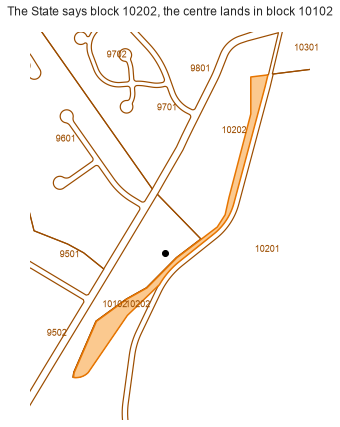

In [13]:
example = disagree[disagree["PAMS_PIN"] == "1114_10202_2_Q0006"].iloc[0]  # the farmland strip along Quaker Road
parcel = state[state["PAMS_PIN"] == example["PAMS_PIN"]].to_crs(metric)
x, y = parcel.geometry.centroid.iloc[0].x, parcel.geometry.centroid.iloc[0].y

minx, miny, maxx, maxy = parcel.total_bounds
pad = 120  # metres of context around the parcel
window = box(minx - pad, miny - pad, maxx + pad, maxy + pad)

fig, ax = plt.subplots(figsize=(7, 7))
blocks.plot(ax=ax, facecolor="none", edgecolor="#9c4d00", linewidth=1.2)
parcel.plot(ax=ax, facecolor="#fbc98f", edgecolor="#e77500", linewidth=1.5)
ax.plot(x, y, marker="o", color="black")
for _, b in blocks.clip(window).iterrows():
    label_at = b.geometry.representative_point()
    ax.annotate(b["BLOCK_NO"], (label_at.x, label_at.y), fontsize=9, color="#9c4d00")
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_title(f"The State says block {example['PCLBLOCK']}, the centre lands in block {example['BLOCK_NO']}")
ax.set_axis_off()

The orange parcel, its centre as the black dot, and the municipality's block lines in brown with their numbers. This one is a long, thin strip along a road, and its centre lies outside its own outline, in the block next door, which is the centroid's failure from 02-02 seen from the other side. Whichever way this particular one resolves, the lesson is the same. A spatial join and an attribute join are two different questions, and on a few percent of the town they give two different answers. A report says which one it asked.

## The inlets nobody inspected

The stormwater inlets carry an inspection date, and for a quarter of them it is empty. The wrong sentence writes itself, i.e. a quarter of Princeton's inlets have never been inspected:

In [14]:
inlets = gpd.read_file("data/princeton_municipal.gpkg", layer="stormwater_inlets")
never = inlets["inspected"].isna()

print(f"{int(never.sum()):,} of {len(inlets):,} inlets have no inspection date   reference {reference['inspections']['never_inspected']:,}")
by_owner = pd.crosstab(inlets["Owner_Type"], never.rename("never inspected"))
by_owner["share never inspected"] = (by_owner[True] / by_owner.sum(axis=1)).round(3)
by_owner

1,119 of 4,455 inlets have no inspection date   reference 1,119


never inspected,False,True,share never inspected
Owner_Type,,,
County,0,131,1.000
Municipality,3236,52,0.016
Other Municipality,84,5,0.056
Private,16,753,0.979
State,0,178,1.000


Now read the table by row. The municipality has inspected nearly every inlet it owns. The county and the State have inspected none of theirs, or at least none that the municipality's file knows about, and the private ones are almost all uninspected too. The one row that does not fit the pattern is the inlets owned by another municipality, nearly all of which carry a date. The quarter is real and the sentence about it is misleading, because the denominator was the wrong one. The right question is not what share of inlets is uninspected but what share of each owner's inlets, and the answer to that is a story about jurisdiction, not neglect. Here is what it looks like on the map:

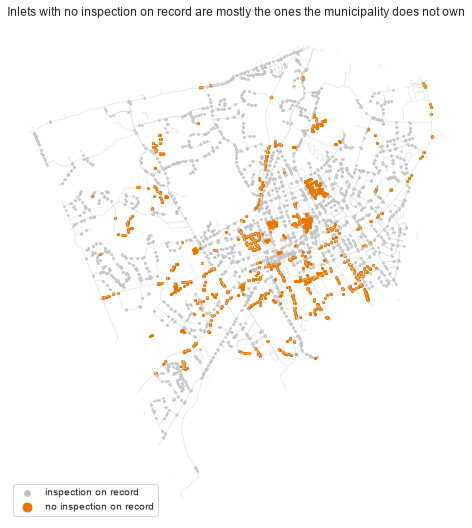

In [15]:
roads = gpd.read_file("data/princeton_municipal.gpkg", layer="roads").to_crs(inlets.crs)

fig, ax = plt.subplots(figsize=(9, 9))
roads.plot(ax=ax, color="#d9d9d9", linewidth=0.5)
inlets[~never].plot(ax=ax, color="#bfbfbf", markersize=2, label="inspection on record")
inlets[never].plot(ax=ax, color="#e77500", markersize=5, label="no inspection on record")
ax.legend(loc="lower left", markerscale=4)
ax.set_title("Inlets with no inspection on record are mostly the ones the municipality does not own")
ax.set_axis_off()

The orange dots run in lines along the county and State roads and cluster in the private developments, i.e. wherever the municipality is not the owner. A map of never inspected is a map of who owns the drain. Note that we aggregated by the owner type, a category with five values, and never by the owner. The private inlets belong to hundreds of people whose names are not in this file, because the municipality did not publish them and this course did not ask for them. That is how a course maps ownership, and it is the decision 02-01 said we would come back to. By class, never by name.

## The inlets that disagree with themselves

One more thing about the inlets. Each row stores its own coordinates twice, once as the geometry and once as an Easting and a Northing typed into columns. For the typical inlet the two agree to the hundredth of a foot, which is the free check on the units that 02-01 ran on this same column, since a geometry in metres or degrees would disagree with these columns by a great deal. For a few they do not:

In [16]:
gap_ft = ((inlets.geometry.x - inlets["Easting"]) ** 2 + (inlets.geometry.y - inlets["Northing"]) ** 2) ** 0.5
off = inlets[gap_ft > 1]

print(f"median gap {gap_ft.median():.4f} ft, {len(off)} inlets more than a foot apart, the worst {gap_ft.max():.0f} ft   reference {reference['inlets']['coordinate_disagreements_over_1ft']}, {reference['inlets']['worst_disagreement_ft']}")
print("by owner:", off["Owner_Type"].value_counts().to_dict(), "  reference", reference["inspections"]["disagreements_by_owner"])
print("the gaps over a foot, in feet:", sorted(gap_ft[gap_ft > 1].round(1)))

median gap 0.0000 ft, 31 inlets more than a foot apart, the worst 223 ft   reference 31, 223
by owner: {'State': 18, 'Municipality': 13}   reference {'State': 18, 'Municipality': 13}
the gaps over a foot, in feet: [2.6, 2.7, 2.7, 2.8, 2.8, 3.1, 3.1, 3.6, 4.3, 5.3, 9.3, 10.3, 11.8, 12.5, 15.2, 21.9, 23.9, 28.6, 29.0, 30.1, 62.5, 66.1, 67.4, 78.3, 90.8, 96.2, 108.1, 208.3, 220.4, 222.4, 223.2]


That is a list, not a map, so let us see where they are, with a line from where the geometry puts each inlet to where its columns do:

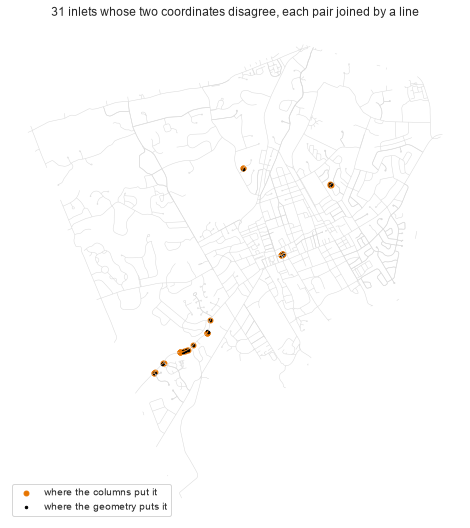

In [17]:
fig, ax = plt.subplots(figsize=(9, 9))
roads.plot(ax=ax, color="#d9d9d9", linewidth=0.5)
for _, row in off.iterrows():
    ax.plot([row.geometry.x, row["Easting"]], [row.geometry.y, row["Northing"]], color="#e77500", linewidth=1)
ax.scatter(off["Easting"], off["Northing"], color="#e77500", s=24, label="where the columns put it")
off.plot(ax=ax, color="black", markersize=6, label="where the geometry puts it")
ax.legend(loc="lower left")
ax.set_title(f"{len(off)} inlets whose two coordinates disagree, each pair joined by a line")
ax.set_axis_off()

Which of the two positions is right? Nothing in the file can tell you, and neither can this notebook. Read the list. The smallest gap is a little over two feet, which is already too large to be a rounding of a surveyed coordinate, and a third of them are more than fifty feet, i.e. a typing error or a record that was moved and only half updated. At the scale of the whole town most of the joining lines are shorter than the dot that sits on them. What you can do is exactly what this cell did. Count them, map them, say who owns them, and hand the list back to the office that keeps the file. That is a finding, and a municipality would rather have a few dozen rows than a sentence saying the data is fine.

## Your turn

The parcels the two authorities agree on and the ones they do not are two different populations. Which property class holds the most assessed value in each? Use `PROP_CLASS` from the State's file, the key you built, and `groupby` with `sum`. Aggregate by class, never by anything that could name a person. Then write one sentence saying whether the disagreement between the two offices is spread across the town or concentrated in one kind of property. Note that only the State's file carries values, so this sentence can only be about the parcels the municipality does not list; the condominium units on the other side have no value column to sum, which is itself worth saying.

In [18]:
# Your attempt.
#
#   state["key"].isin(municipal["key"])                   which State parcels have a municipal twin
#   state.groupby("PROP_CLASS")["NET_VALUE"].sum()         assessed value by class
#   .sort_values(ascending=False).head()                   the top of the list

## Check your understanding

1. Slicing the block out of `propid` and turning it into a number gave zero matches against the State's block column, with no error. What were the two things being compared, and why did pandas consider none of them equal?
2. The naive key matched fewer than a thousand parcels and the fixed key matched almost all of them. What single decision about missing values made the difference, and where did it have to be made?
3. The address join found more matches than the key. Why is that a reason to trust it less rather than more?
4. A quarter of the inlets have no inspection date. Write the sentence that is true and misleading, and the sentence that is true and fair, and name the denominator each one uses.

## Where we are

You have joined two authorities' files on a key you built, after watching a number fail to equal a string, a missing value refuse to become text, and an address match too well. You have counted what the two offices disagree about and read the reasons off the qualifiers. You have seen a spatial join and an attribute join answer the same question differently, and you have turned a misleading quarter into a fair table by changing its denominator. And you have found the inlets whose two recorded positions disagree, counted them, mapped them and named their owners, which is a list to hand back to the office rather than a sentence to write. Every one of those is a sentence in a caption, and none of them was an error message.

## Further resources

Nothing in this course requires anything below.

The property class codes, i.e. what 2, 4A, 3B and the 15 series mean, are defined by the New Jersey Division of Taxation in its handbook for assessors and its MOD-IV documentation, both listed on its reference materials page: https://www.nj.gov/treasury/taxation/lpt/referencematerials.shtml

The statewide parcel composite and its documentation, including the meaning of the PAMS_PIN and the disclaimer that the parcels are not survey data, are on NJGIN Open Data: https://njogis-newjersey.opendata.arcgis.com/

The pandas guide to merging and joining explains the one-to-one, one-to-many and many-to-many cases, and its `validate` argument is the built-in version of the check this notebook did by hand: https://pandas.pydata.org/docs/user_guide/merging.html

The parcels are from NJGIN Open Data and the Municipality of Princeton, the blocks, roads and inlets from the Municipality of Princeton, as listed in the data folder's README.

## Appendix, in case you are stuck

Try properly first. If you do use this, treat it the way you would treat an agent's answer. Read it, run it, and say why yours differed.

```python
import geopandas as gpd

municipal = gpd.read_file("data/princeton_municipal.gpkg", layer="parcels")
state = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels")


def key(block, lot, qualifier):
    q = qualifier.fillna("").astype(str).str.strip().str.upper()
    return block.astype(str).str.strip() + "_" + lot.astype(str).str.strip() + "_" + q


state["key"] = key(state["PCLBLOCK"], state["PCLLOT"], state["PCLQCODE"])
twin = state["key"].isin(key(municipal["block"], municipal["lot"], municipal["qualifier"]))

agreed = state[twin].groupby("PROP_CLASS")["NET_VALUE"].sum().sort_values(ascending=False)
disputed = state[~twin].groupby("PROP_CLASS")["NET_VALUE"].sum().sort_values(ascending=False)
print("agreed on, top classes by value\n", (agreed / 1e6).round(1).head())
print("not in the municipal file, top classes by value\n", (disputed / 1e6).round(1).head())
```

Note that both lists are led by the same class, ordinary residential property, because that is most of the town whichever way you cut it. The lists differ below the top. Which classes appear high in the second list and barely in the first is the sentence for your caption, and it is about the offices, not about the town.